# OLX Ko'chmas mulk — Malumot Tozalash jaroyoni  
Kodni tepadan paga qarab yurg'azing. Oxirida sizda tayor `cleaned.csv` fileli modeling uchun tayor bo'ladi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

In [2]:
df = pd.read_csv('../data/Praperad/olx_apartments.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 93,475 rows, 29 columns


In [3]:
df.isna().sum()

listing_id             0
source                 0
seller_type            1
housing_type       32722
region                 1
district               1
rooms                  7
living_area_m2     61499
kitchen_area_m2    71050
total_area_m2         20
floor                  9
total_floors           7
building_type      23197
layout             33510
build_year         64984
ceiling_height     59326
bathroom           26220
furnished             12
renovation         17649
commission             7
amenities          34100
nearby             30316
negotiable             0
price                226
currency               0
published_date         1
description            1
date_scraped           0
url                    0
dtype: int64

In [4]:
df.head()

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
0,4jYx9,olx,private,resale,Tashkent Region,Chilanzar District,1.0,20.0,6.0,29.0,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",1,60000.0,USD,01/05/2026,Описание Уй локацияси зур жойда жойлашган. Мир...,2026-05-02,https://www.olx.uz/d/obyavlenie/1-hona-metro-o...
1,4myoT,olx,private,NaN,Tashkent Region,Yunusabad District,2.0,80.0,NaN,80.0,...,1.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,7865000.0,UZS,30/04/2026,Описание Сдается в аренду 2/6/13 Юнусабад 13 к...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
2,4lvjL,olx,business,new building,Tashkent Region,Yunusabad District,3.0,NaN,NaN,80.0,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, School, Playground, Kinderga...",0,220000.0,USD,29/04/2026,Описание Продается квартира !!! 3/6/9 80 кВ По...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-prodae...
3,4aiOy,olx,private,NaN,Tashkent Region,Shaykhantakhur District,3.0,67.5,NaN,67.5,...,0.0,"Internet, Refrigerator, TV, Air Conditioning, ...",NaN,0,1400.0,USD,02/05/2026,"Описание Квартира в новостройке Tashkent City,...",2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
4,4mAGS,olx,business,resale,Tashkent Region,Yashnabad District,3.0,50.0,NaN,78.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,120000.0,USD,02/05/2026,Описание Продается своя квартира 3/1/4 Кирпичн...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-3-1-4...


## A. Malumotna uchun shartnoma

# Ma'lumotlar lug'ati — OLX.uz kvartiralar dataseti
 
> **Hajmi:** 83 000+ qator × 28 ustun  
> **Manba:** OLX.uz — kvartiralar bo'limi (`/nedvizhimost/kvartiry/`)  
> **Skraping sanasi:** 2026-04-15 - hozir

## B. Ma'lumotlarni qabul qilish va dastlabki tekshiruvlar

### B.1. Asosiy qabul qilish ro'yxati:

In [5]:
print(f'File nomi: olx_apartments.csv')
print(f'Qatorlar soni: {df.shape[0]}')
print(f'Ustunlar soni: {df.shape[1]}')
print(f"Ustun nomlari malumot ustuniga o'xshashmimi: (Ha/yoq): Ha")

File nomi: olx_apartments.csv
Qatorlar soni: 93475
Ustunlar soni: 29
Ustun nomlari malumot ustuniga o'xshashmimi: (Ha/yoq): Ha


### B.2. Noyoblik + dublikatlar (Dunyo talabi)

In [6]:
before = len(df)
after = df.duplicated().sum()
print(f"Dublikatlar soni: {after}")
print(f'Noyoblik soni: {before-after}')
df_cleaned = df.drop_duplicates()

Dublikatlar soni: 3269
Noyoblik soni: 90206


### B.3. Natija yaxlitligini tekshirish
  
>Faqatgina ko'zlangan malumonni o'z ichaga oladimi? (yani narxni)  
* 2 hil turdaki valyuta aralashgan UZB va USD.
>Biror yoqolgan qiymatlar bormi?
* Bor 50 rotiq
>G‘alati yozilgan (imlosi noto‘g‘ri) so‘zlar bormi?
* Hozircha kuzatilmadi

## C. Malumot sifati (Nima hato ekanligini isbotlash)
  
### C.1. Yetishmayotgan Qiymatlar Profili
 
**Dataset hajmi:** 18,267 qator (`price` ustunidagi 40 ta bo'sh qiymat o'chirilgandan keyin)
 
---
 
## Yetishmayotgan Qiymatlar Jadvali
 
| Ustun | Yetishmaydi (n) | % | Qabul qilinadimi? | Nega yetishmayotgan bo'lishi mumkin? |
|---|---|---|---|---|
| listing_id | 0 | 0.0% | ✅ Ha | — |
| seller_type | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| housing_type | 5,956 | 32.6% | ⚠️ Balki | Forma to'ldirishda majburiy emas |
| region | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| district | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| rooms | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| living_area_m2 | 12,862 | 70.4% | ❌ Yo'q | Sotuvchilar ko'pincha maydon ma'lumotini qoldirmaydi |
| kitchen_area_m2 | 14,775 | 80.9% | ❌ Yo'q | Alohida ko'rsatilmaydi; ixtiyoriy maydon |
| total_area_m2 | 4 | 0.0% | ✅ Ha | Deyarli to'liq |
| floor | 2 | 0.0% | ✅ Ha | Deyarli to'liq |
| total_floors | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| building_type | 4,488 | 24.6% | ⚠️ Balki | Sotuvchi har doim bilmasligi mumkin |
| layout | 6,378 | 34.9% | ⚠️ Balki | Ixtiyoriy maydon; subyektiv tasnif |
| build_year | 13,785 | 75.5% | ❌ Yo'q | Eski binolarda hujjat yo'q bo'lishi mumkin |
| ceiling_height | 12,486 | 68.4% | ❌ Yo'q | E'lonlarda kamdan-kam ko'rsatiladi |
| bathroom | 5,057 | 27.7% | ⚠️ Balki | Ko'p formatlarda ixtiyoriy |
| furnished | 3 | 0.0% | ✅ Ha | Deyarli to'liq |
| renovation | 3,370 | 18.4% | ⚠️ Balki | Sotuvchi ta'mirlash holatini ko'rsatmasligi mumkin |
| commission | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| amenities | 7,045 | 38.6% | ⚠️ Balki | Ixtiyoriy maydon; har doim to'ldirilmaydi |
| nearby | 6,523 | 35.7% | ⚠️ Balki | Ixtiyoriy qo'shimcha maydon |
| negotiable | 0 | 0.0% | ✅ Ha | — |
| price | 40 | 0.2% | ❌ Yo'q | Maqsad ustun — to'liq bo'lishi shart; o'chirildi |
| currency | 0 | 0.0% | ✅ Ha | — |
| published_date | 1 | 0.0% | ✅ Ha | Kichik ma'lumot kiritish xatosi |
| description | 1 | 0.0% | ✅ Ha | Deyarli to'liq |
| date_scraped | 0 | 0.0% | ✅ Ha | — |
| url | 0 | 0.0% | ✅ Ha | — |
 
---
 
## Yetishmayotgan Qiymatlar Tahlili
 
### Yetishmayotgan qiymatlar tasodifiy yoki tizimliymi?
 
Bu datasetdagi yetishmayotgan qiymatlar **to'liq tasodifiy emas**. `living_area_m2` (70.4%), `kitchen_area_m2` (80.9%), `build_year` (75.5%) va `ceiling_height` (68.4%) ustunlarida qiymatlarning aksariyati yo'q. Bu **tizimli muammo**ni ko'rsatadi: ushbu maydonlar platforma formasida ixtiyoriy bo'lgan yoki sotuvchilar ularni to'ldirishni istamagan.
 
### Yetishmayotgan qiymatlar narx (price) bilan bog'liqmi?
 
Jismoniy xususiyatlari (maydon, qurilish yili, shift balandligi) ko'rsatilmagan e'lonlar **past sifatli yoki norasmiy** bo'lishi mumkin, bu esa narxlarning ham past bo'lishiga olib keladi. Agar shunday bo'lsa, bu ustunlarni o'rtacha qiymat bilan to'ldirish (imputation) **narx bashoratlarini yuqori tomonga siljitishi** mumkin.
 
### Guruhlar bo'yicha yetishmayotgan % ni tekshirish (tavsiya)
 
```python
# housing_type bo'yicha yetishmayotgan %
df.groupby('housing_type').apply(lambda x: x.isnull().mean() * 100)
 
# region bo'yicha yetishmayotgan %
df.groupby('region').apply(lambda x: x.isnull().mean() * 100)
```
 
### Xulosa
 
Yetishmayotgan qiymatlar **qisman tizimli** xarakterga ega: `living_area_m2`, `kitchen_area_m2`, `build_year` va `ceiling_height` ustunlarida 68–81% qiymat yo'q, chunki platforma ularni ixtiyoriy maydon sifatida ko'rsatadi. Bu oddiy xato emas — bu sotuvchilarning e'lon to'ldirishdagi tarkibiy kamchiligidir. Modellashtirish oldidan ushbu ustunlar uchun qaror qabul qilish kerak: **ustunlarni o'chirish**, **ehtiyotkorlik bilan to'ldirish (imputation)**, yoki **yetishmayotganlikni alohida belgi (binary flag) sifatida saqlash**.

### Amal qiladigan oralag'i columnlar uchun
  
---
 
| Ustun | Ma'nosi | Turi | Mumkin qiymatlar / diapazon | O'lchov birligi | Izohlar |
| --- | --- | --- | --- | --- | --- |
| `listing_id` | E'lon unikal identifikatori | string | `'4jYx9'` kabi 5 belgili alfanumerik kod | — | OLX tomonidan avtomatik beriladi; asosiy kalit (primary key) sifatida ishlatiladi |
| `seller_type` | Sotuvchi turi | kategoriya | `private`, `business` | — | `private` — uy egasi o'zi; `business` — agentlik yoki firma |
| `housing_type` | Uy-joy turi | kategoriya | `resale`, `new building` | — | 2 834 ta qiymat yo'q; ko'pchilik `resale` |
| `region` | Viloyat | kategoriya | `Tashkent Region` va boshqa viloyatlar | — | Hozirgi ma'lumotlarda asosan Toshkent viloyati |
| `district` | Tuman / mahalla | kategoriya | `Chilanzar District`, `Yunusabad District` va boshqalar | — | Narx prognozi uchun eng muhim ustunlardan biri |
| `rooms` | Xonalar soni | raqam | `1` — `6+` | dona | Butun son kutiladi; modelda kategoriya sifatida ham ishlatish mumkin |
| `living_area_m2` | Yashash maydoni | raqam | taxminan `10` — `200` | m² | 5 777 ta qiymat yo'q (66%); mediana bilan to'ldirish + `missing` flagi tavsiya etiladi |
| `kitchen_area_m2` | Oshxona maydoni | raqam | taxminan `4` — `30` | m² | 6 656 ta qiymat yo'q (76%); yuqori yo'qotish darajasi |
| `total_area_m2` | Umumiy maydon | raqam | taxminan `15` — `500` | m² | Faqat 1 ta qiymat yo'q; narx prognozi uchun asosiy ustun |
| `floor` | Qavat | raqam | `1` — `30+` | qavat | 1 ta qiymat yo'q; mediana bilan to'ldirish yetarli |
| `total_floors` | Binodagi jami qavatlar soni | raqam | `2` — `30+` | qavat | Qiymat yo'q emas; `floor / total_floors` nisbati yaratish tavsiya etiladi |
| `building_type` | Bino turi | kategoriya | `panel`, `brick`, `monolith` | — | 2 029 ta qiymat yo'q; eng ko'p uchraydigan qiymat bilan to'ldirish |
| `layout` | Xonalar tartibi | kategoriya | `adjacent`, `separate`, `Смежно-раздельная` | — | Aralash til (rus/ingliz) bor — tozalash kerak; 2 840 ta qiymat yo'q |
| `build_year` | Qurilgan yil | raqam | `1950` — `2026` | yil | 6 197 ta qiymat yo'q; `building_age = 2026 - build_year` ustuni hosil qilish tavsiya etiladi |
| `ceiling_height` | Shift balandligi | raqam | `2.5` — `4.0` | metr | 5 683 ta qiymat yo'q; mediana bilan to'ldirish |
| `bathroom` | Hammom turi | kategoriya | `separate`, `combined` | — | 2 312 ta qiymat yo'q; eng ko'p uchraydigan qiymat bilan to'ldirish |
| `furnished` | Mebel mavjudligi | ikkilik (binary) | `1` — mebel bor, `0` — yo'q | — | Faqat 2 ta qiymat yo'q |
| `renovation` | Ta'mirlash holati | kategoriya | `euro renovation`, `average condition`, `designer renovation` | — | 1 538 ta qiymat yo'q; narxga sezilarli ta'sir ko'rsatadi |
| `commission` | Vositachi komissiyasi | ikkilik (binary) | `0` — yo'q, `1` — bor | — | Qiymat yo'q emas; `1` bo'lsa agentlik orqali sotiladi |
| `amenities` | Jihozlar ro'yxati | vergul bilan ajratilgan string | `Internet`, `TV`, `Air Conditioning`, `Balcony`, `Washing Machine` va boshqalar | — | 3 187 ta qiymat yo'q = jihozlar ko'rsatilmagan; multi-hot encoding tavsiya etiladi |
| `nearby` | Yaqin atrofdagi ob'ektlar | vergul bilan ajratilgan string | `School`, `Bus Stop`, `Park`, `Hospital`, `Supermarket` va boshqalar | — | 2 874 ta qiymat yo'q; multi-hot encoding tavsiya etiladi |
| `negotiable` | Narx kelishiladi | ikkilik (binary) | `1` — ha, `0` — yo'q | — | Qiymat yo'q emas |
| `price` | Narx | raqam | `500` — `2 000 000` (USDga o'tkazilgandan keyin) | USD yoki UZS | 13 ta qiymat yo'q — bu qatorlarni o'chirish kerak; avval valyutani normallashtirish shart |
| `currency` | Valyuta | kategoriya | `USD`, `UZS` | — | Modelga kirishdan oldin hammasi USDga aylantiriladi (1 USD ≈ 12 700 UZS) |
| `published_date` | E'lon joylashtirilgan sana | sana | `DD/MM/YYYY` formatida | sana | Modelda `days_since_posted` ustuniga aylantirish mumkin |
| `description` | E'lon matni | erkin matn | Rus va o'zbek tillarida | — | Modelga kiritilmaydi; NLP tahlili uchun alohida ishlatish mumkin |
| `date_scraped` | Skraping sanasi | sana | `YYYY-MM-DD` formatida | sana | Barcha qatorlarda `2026-05-02`; modelda ishlatilmaydi |
| `url` | E'lon havolasi | string | `https://www.olx.uz/d/obyavlenie/...` | — | Modelda ishlatilmaydi; manba sifatida saqlab qo'yish tavsiya etiladi |
 
---
 
## Tozalash bo'yicha qisqacha yo'riqnoma
 
| Muammo | Ta'sirlangan ustunlar | Yechim |
| --- | --- | --- |
| Maqsadli qiymat yo'q | `price` (13 ta) | Qatorlarni o'chirish |
| Yuqori yo'qotish (>50%) | `living_area_m2`, `kitchen_area_m2`, `build_year`, `ceiling_height` | Mediana bilan to'ldirish + `_missing` flagi |
| O'rtacha yo'qotish | `housing_type`, `building_type`, `layout`, `bathroom`, `renovation` | Eng ko'p uchraydigan qiymat (mode) bilan to'ldirish |
| Aralash valyuta | `price`, `currency` | Hammasi USDga o'tkazish |
| Aralash til | `layout` | `Смежно-раздельная` → `mixed` deb standartlashtirish |
| Vergul bilan ajratilgan qiymatlar | `amenities`, `nearby` | Multi-hot encoding (har bir teg — alohida ustun) |

## D. Tozalash strategiyasi (nafaqat qadamlar-qarorlar)
  
### D.1 Standartlashtirish qoidalari (kategoriyaviy)
`seller_type` --> Faqatgina 2 dona categoria aniqlandi. Ortiqcha tekshiruv talab qilmaydi.  
`housing_type` --> 6 ga yaqin categoria aniqladi. Uchta rus tilodagi miqdorlar("новостройка", "Новостройка", "Новостройка.") --> new building  
`region` -- > Hammasi joyida.


In [7]:
df_cleaned['district'].value_counts()

district
Mirzo-Ulugbek District    14258
Yunusabad District        10229
Yakkasaray District        8977
Yashnabad District         8554
Mirabad District           8384
                          ...  
Талимарджан                   1
Обмен - Алмалык               1
Обмен - Фергана               1
Чалыш                         1
Кумкурган                     1
Name: count, Length: 197, dtype: int64

---

## Price malumot tozalash

In [8]:
df_cleaned[df_cleaned['price'].isnull()]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
1314,4mwtN,olx,private,NaN,Tashkent Region,Бектемирский район,3.0,45.0,12.0,66.0,...,0.0,"Internet, Refrigerator, TV, Cable TV, Washing ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,NaN,USD,29/04/2026,Описание Musaffo maskan 3/6/10 400$ ichida ha...,2026-05-02,https://www.olx.uz/d/obyavlenie/musaffo-maskan...
2126,4ms7L,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,2.0,56.0,NaN,56.0,...,1.0,NaN,NaN,1,NaN,USD,01/05/2026,Описание Мирзо-Улугбекский район ЖК Akay City ...,2026-05-02,https://www.olx.uz/d/obyavlenie/akay-city-2-ko...
3926,4mCMT,olx,business,new building,Tashkent Region,Yashnabad District,2.0,NaN,NaN,60.0,...,1.0,NaN,NaN,0,NaN,USD,02/05/2026,Описание Срочно Продаётся Новостройка 2 комнат...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-novost...
4431,4mCEI,olx,business,NaN,Tashkent Region,Yashnabad District,2.0,NaN,NaN,52.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, Playground, Kindergarten, Bu...",1,NaN,USD,02/05/2026,Описание Район: Яшнабод Ориентир: Better best ...,2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-kvartir...
4624,4lDkg,olx,business,NaN,Обмен - Ферганская область,Обмен - Маргилан,3.0,56.0,15.0,56.0,...,0.0,"Telephone, Cable TV, TV, Internet","Entertainment, Bus Stop, School, Supermarket, ...",0,NaN,USD,02/05/2026,Описание Ijaraga beriladi yoki hovli uyga bart...,2026-05-02,https://www.olx.uz/d/obyavlenie/dom-ijaraga-be...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89806,4oVEO,olx,business,NaN,Tashkent Region,Shaykhantakhur District,2.0,60.0,60.0,60.0,...,1.0,"Internet, Telephone, Refrigerator, Washing Mac...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,NaN,USD,21/06/2026,Описание Bola qizla ham beriladi soni farq yo...,2026-06-26,https://www.olx.uz/d/obyavlenie/sebzor-arenda-...
90949,4p8UD,olx,business,new building,Tashkent Region,Chilanzar District,2.0,42.0,6.0,48.0,...,0.0,"Telephone, TV, Air Conditioning, Washing Machi...","Entertainment, Bus Stop, School, Supermarket, ...",1,NaN,USD,22/06/2026,Описание Жк Арт Хаус 2/8/10. 2 хона + бал...,2026-06-27,https://www.olx.uz/d/obyavlenie/art-haus-2-hon...
91467,4pmzo,olx,private,NaN,Tashkent Region,Mirabad District,1.0,14.0,15.0,30.0,...,0.0,"Internet, Refrigerator, Kitchen","Hospital, Clinic, Playground, Bus Stop, Park, ...",0,NaN,USD,27/06/2026,Описание Mirobod tumani Sarikoʻlda obshita bor...,2026-06-27,https://www.olx.uz/d/obyavlenie/obshita-mirobo...
91931,3QWbi,olx,private,NaN,Обмен - Самаркандская область,Обмен - Самарканд,3.0,70.0,10.0,70.0,...,1.0,"Telephone, Cable TV, Internet, Air Conditionin...",School,0,NaN,USD,27/06/2026,Описание Kvartira shahar markazida joylashgan....,2026-06-27,https://www.olx.uz/d/obyavlenie/kvartirani-hov...


In [9]:
df_cleaned[df_cleaned['currency'] == "UZS"]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,commission,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url
1,4myoT,olx,private,NaN,Tashkent Region,Yunusabad District,2.0,80.0,NaN,80.0,...,1.0,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,7865000.0,UZS,30/04/2026,Описание Сдается в аренду 2/6/13 Юнусабад 13 к...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...
24,49bVu,olx,private,NaN,Samarkand Region,Лаиш,2.0,65.0,NaN,10.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",0,4000000.0,UZS,02/05/2026,Описание Samarqand shahar Qorasuv massiv 2 xon...,2026-05-02,https://www.olx.uz/d/obyavlenie/bez-agestvo-ij...
29,4lwkw,olx,private,NaN,Khorezm Region,Ургенч,3.0,49.0,10.0,62.0,...,0.0,"Refrigerator, TV, Air Conditioning, Washing Ma...","Hospital, Clinic, School, Playground, Kinderga...",0,2800000.0,UZS,02/05/2026,Описание Ургенч шахар марказида мед институтга...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-izhar...
30,3nWuH,olx,private,resale,Samarkand Region,Samarkand,5.0,86.0,12.0,100.0,...,0.0,"Kitchen, Balcony","Hospital, Clinic, Playground, Kindergarten, Bu...",0,900000000.0,UZS,02/05/2026,Описание 5 хона 6 хона килинган квартира сотил...,2026-05-02,https://www.olx.uz/d/obyavlenie/6-honalik-kvar...
33,3It0w,olx,private,NaN,Tashkent Region,Yashnabad District,4.0,100.0,12.0,92.0,...,1.0,"Internet, Telephone, Refrigerator, TV, Air Con...","School, Playground, Kindergarten, Bus Stop, Pa...",1,1300000.0,UZS,02/05/2026,"Описание Квартирага боллани куяман, 1.300 000...",2026-05-02,https://www.olx.uz/d/obyavlenie/kvartiraga-ish...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93447,4poG7,olx,private,resale,Khorezm Region,Ургенч,1.0,18.0,16.0,32.0,...,0.0,"Refrigerator, TV, Balcony",NaN,0,260000000.0,UZS,28/06/2026,"Описание Урганч Шахар, А.Беруний кучаси, 7 Уй,...",2026-06-28,https://www.olx.uz/d/obyavlenie/1-honali-zhoy-...
93448,4poFV,olx,private,NaN,Tashkent Region,Бектемирский район,10.0,12.0,20.0,100.0,...,0.0,"Telephone, Internet, Washing Machine, Kitchen,...","Entertainment, Bus Stop, School, Supermarket, ...",0,900000.0,UZS,28/06/2026,"Описание Assalomu alaykum, Sergeli Yangihayot ...",2026-06-28,https://www.olx.uz/d/obyavlenie/kvartira-qizla...
93455,47LqB,olx,private,NaN,Fergana Region,Фергана,3.0,71.0,12.0,71.0,...,0.0,Internet,"Bus Stop, Parking, School",0,2000000.0,UZS,28/06/2026,"Описание Manzil: Farg‘ona shahri, Kirgili hudu...",2026-06-28,https://www.olx.uz/d/obyavlenie/ijara-3-xonali...
93469,4poyA,olx,private,resale,Navoiy Region,Кармана,3.0,50.0,8.0,58.0,...,0.0,"Washing Machine, Internet, Kitchen","Parking, Bus Stop, Supermarket, Shops, Park, G...",0,430000000.0,UZS,27/06/2026,Описание 3-xonali juda shinam uy sotiladi! Kre...,2026-06-28,https://www.olx.uz/d/obyavlenie/kvartira-sotil...


In [10]:
# Birinchi bo'lib narxi yo'q qatorlarni olib tashlaymiz
before1 = len(df_cleaned['price'])
df_cleaned.dropna(subset=['price'], inplace=True)
print(f"Qatorlar soni(Dublikat bilan): {before1}")
print(f"Olib tashlangan qator soni: {before1 - len(df_cleaned['price'])}")
print(f"Noyoblik soni: {len(df_cleaned['price'])}")

# Endi bir xil valyutaga o'tqazib olamiz
exchange_rate = 12700
df_cleaned['price_usd'] = df_cleaned['price']
df_cleaned.loc[df_cleaned['currency']=="UZS", 'price_usd'] = (
    df_cleaned.loc[df_cleaned['currency']=="UZS", 'price_usd'] / exchange_rate
).round(1)

Qatorlar soni(Dublikat bilan): 90206
Olib tashlangan qator soni: 214
Noyoblik soni: 89992


/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_47939/3476733231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.dropna(subset=['price'], inplace=True)
/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_47939/3476733231.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['price_usd'] = df_cleaned['price']


Hozirda 3 savdo turdaki uylar OLXda joylngan.  
Bu muammo OLX tomonidan amalga oshirilgan bo'lishi mumkin va natijada bu malumotni tozalash qiyinchiligiga olip keladi.  
Bu muammoni yechish uch ikki turdaki yechim mavjud. Biri narx orqali savdo turini aniqlash va ikkinchi esa commetaria orqali.

In [11]:
df_cleaned.loc[(df_cleaned['price_usd'] < 30000) & (df_cleaned['price_usd'] > 3000), ["price_usd","description"]]

,price_usd,description
14,29000.0,Описание Продаётся 2х комнатная квартира в хор...
42,14173.2,Описание Нокис каласы Коскол 3 жолға жакын 4 х...
59,22440.9,Описание Квартира сотилади 45 м² 2 хона + кухн...
73,25196.9,Описание SROCHNA SOTILADI PUL ZARUR parkentda ...
88,26200.0,Описание Текстил Бурж аптека енида жойлашган 4...
...,...,...
93378,26000.0,"Описание Срочно продам квартиру собственник, м..."
93380,28000.0,"Описание Продажа квартиры, бывшее общежитие. О..."
93391,18000.0,Описание ПРОДАЁТСЯ КВАРТИРА 18000 у/е В ЯНГИХА...
93414,25800.0,Описание Мирзо Улугбек тумани ТТЗ -2. Навруз б...


In [12]:
df_cleaned[(df_cleaned['price_usd'] > 3000) & (df_cleaned['price_usd'] < 5000)]

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,amenities,nearby,negotiable,price,currency,published_date,description,date_scraped,url,price_usd
310,4iYGx,olx,business,NaN,Tashkent Region,Mirabad District,4.0,NaN,NaN,230.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,4499.0,USD,01/05/2026,Описание Срочно Сдаётся Новостройка Ж/К Mirab...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-sdaets...,4499.0
1430,4lZm3,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,NaN,NaN,190.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,3500.0,USD,29/04/2026,Описание 20.04.2026 • Район: Мирабад • Мирабад...,2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-zhk-mir...,3500.0
1510,4mvif,olx,private,NaN,Tashkent Region,Алмазарский район,3.0,70.0,20.0,80.00,...,"Air Conditioning, Refrigerator, Washing Machin...","Restaurant, Cafe, Kindergarten, Parking, Bus S...",0,3490.0,USD,02/05/2026,"Описание Нестван А блок 40 этаж, этажность 51 ...",2026-05-02,https://www.olx.uz/d/obyavlenie/nestone-a-blok...,3490.0
1623,4lGcq,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,180.0,NaN,200.00,...,"Internet, Telephone, Refrigerator, TV, Air Con...","Hospital, Clinic, School, Playground, Kinderga...",1,4000.0,USD,29/04/2026,"Описание -Реальная цена, реальные фото -14.04....",2026-05-02,https://www.olx.uz/d/obyavlenie/arenda-kvartir...,4000.0
1724,4locg,olx,private,NaN,Tashkent Region,Mirabad District,3.0,240.0,40.0,300.00,...,NaN,NaN,0,3500.0,USD,08/04/2026,Описание Роскошная вилла в корейском стиле сда...,2026-05-02,https://www.olx.uz/d/obyavlenie/elitnaya-kvart...,3500.0
3479,3riNq,olx,business,NaN,Tashkent Region,Yakkasaray District,4.0,220.0,NaN,220.00,...,"Kitchen, TV, Balcony, Air Conditioning, Intern...","Restaurant, Cafe, Kindergarten, Parking, Bus S...",0,3500.0,USD,02/05/2026,Описание Сдаётся Квартира в центре Габусе #О...,2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-kvart...,3500.0
5753,4mDuc,olx,private,new building,Tashkent Region,Yunusabad District,1.0,29.0,NaN,29.00,...,"Internet, Cable TV, Balcony","Hospital, Clinic, Playground, Kindergarten, Bu...",0,3500.0,USD,02/05/2026,"Описание Юнусабад, Бетонка, ориентир Уч Кахрам...",2026-05-02,https://www.olx.uz/d/obyavlenie/1-komnatnaya-k...,3500.0
6101,4kQpz,olx,business,NaN,Tashkent Region,Mirabad District,4.0,NaN,NaN,200.00,...,NaN,NaN,1,4000.0,USD,02/05/2026,Описание Мирабадский район Жк Mirabad Avenue П...,2026-05-02,https://www.olx.uz/d/obyavlenie/mirabad-avenue...,4000.0
11642,3WTjS,olx,business,NaN,Tashkent Region,Mirzo-Ulugbek District,7.0,400.0,15.0,400.00,...,"Telephone, Cable TV, Internet, Air Conditionin...","School, Supermarket, Shops, Park, Green Area, ...",0,4000.0,USD,03/05/2026,"Описание Сдается 7комната 2этажность 400кв, 7к...",2026-05-03,https://www.olx.uz/d/obyavlenie/sdaetsya-7komn...,4000.0
12475,4mGnz,olx,private,NaN,Navoiy Region,Navoiy,3.0,94.0,4.0,94.00,...,"Internet, Refrigerator, TV, Air Conditioning, ...","Hospital, Clinic, Playground, Kindergarten, Bu...",0,40000000.0,UZS,03/05/2026,Описание 3 хона 1 етаж полностью абстанофка иж...,2026-05-03,https://www.olx.uz/d/obyavlenie/srochna-izhara...,3149.6


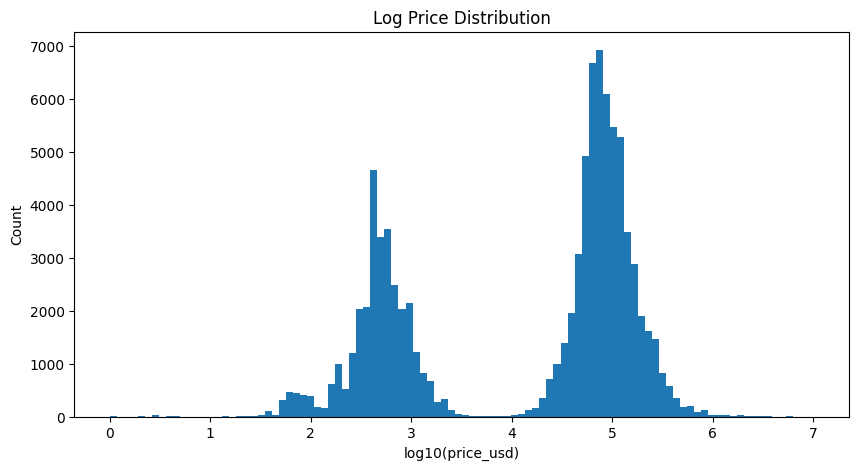

In [13]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned["price_usd"] + 1), bins=100)
plt.xlabel("log10(price_usd)")
plt.ylabel("Count")
plt.title("Log Price Distribution")
plt.show()

In [14]:
df_cleaned["listing_type"] = "Unknown"

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_47939/13968768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["listing_type"] = "Unknown"


In [15]:
import re

RENT_MAX_PRICE = 2000
SALE_MIN_PRICE = 10000

def listing_type_scores(df):
    desc = df["description"].fillna("").str.lower()
    url = df["url"].fillna("").str.lower()

    rent_words = [
        "сдаётся", "сдается", "сдам", "сдаю", "аренда", "аренду",
        "посуточно", "помесячно",
        "ижарага", "ижара", "ijaraga", "ijara", "ijaraga beriladi",
        "topshiriladi", "арендага",
        "for rent", "to rent", "lease", "tenant"
    ]

    sale_words = [
        "продаётся", "продается", "продам", "продаю", "продажа",
        "сотилади", "sotiladi", "sotaman", "sotuv", "sotish",
        "ипотека", "рассрочка", "ipoteka",
        "for sale", "sell", "selling", "mortgage"
    ]


    rent_score = (
        sum(desc.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in rent_words) * 3
        + sum(url.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in rent_words)
    )

    sale_score = (
        sum(desc.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in sale_words) * 3
        + sum(url.str.contains(re.escape(w), regex=True, na=False).astype(int) for w in sale_words)
    )

    return rent_score, sale_score


def classify_listings(df):
    rent_score, sale_score = listing_type_scores(df)
    price = df["price_usd"]

    conditions = [
        (sale_score > rent_score) & (price >= RENT_MAX_PRICE),
        (rent_score > sale_score) & (price < SALE_MIN_PRICE),
        (sale_score > rent_score) & (price < RENT_MAX_PRICE),
        (rent_score > sale_score) & (price >= SALE_MIN_PRICE),
        price >= SALE_MIN_PRICE,
    ]

    choices = ["Sale", "Rent", "Rent", "Sale", "Sale"]

    return np.select(conditions, choices, default="Rent")


df_cleaned["listing_type"] = classify_listings(df_cleaned)

# Sanity check
rent_score, sale_score = listing_type_scores(df_cleaned)

print(df_cleaned["listing_type"].value_counts())
print(f"\nAmbiguous both-hit rows: {((rent_score > 0) & (sale_score > 0)).sum()}")
print(f"No keyword rows: {((rent_score == 0) & (sale_score == 0)).sum()}")

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_47939/2076063578.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["listing_type"] = classify_listings(df_cleaned)


listing_type
Sale    58127
Rent    31865
Name: count, dtype: int64

Ambiguous both-hit rows: 1718
No keyword rows: 36749


In [16]:
df_cleaned["price_per_sqr"] = np.nan

sale_mask = (
    (df_cleaned["listing_type"] == "Sale") &
    (df_cleaned["total_area_m2"].notna()) &
    (df_cleaned["total_area_m2"] > 0)
)

df_cleaned.loc[sale_mask, "price_per_sqr"] = round(
    (df_cleaned.loc[sale_mask, "price_usd"] /
    df_cleaned.loc[sale_mask, "total_area_m2"]
), 2)

/var/folders/pn/2q111n451j10mgh135bwncf00000gn/T/ipykernel_47939/324250605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["price_per_sqr"] = np.nan


In [17]:
MAX_PRICE_PER_SQR = 50000

df_cleaned = df_cleaned[
    ~(
        (df_cleaned["listing_type"] == "Sale") &
        (df_cleaned["price_per_sqr"] > MAX_PRICE_PER_SQR)
    )
].copy()

---

## `listing_id` malumot tozalash

In [18]:
print(f"listing_id dublikatlar soni: {len(df_cleaned)-len(df_cleaned['listing_id'].unique())}")

listing_id dublikatlar soni: 261


Qaysidir sabab orqali `listing_id` o'z ichiga dublikatlarni oladi.

In [19]:
print(f"Dublikatlar soni: {len(df_cleaned)}")
df_cleaned = df_cleaned.drop_duplicates(subset=['listing_id'])
print(f'Noyoblik soni dublikatlarni olib tashlangandam keyin: {len(df_cleaned)}')

Dublikatlar soni: 89907
Noyoblik soni dublikatlarni olib tashlangandam keyin: 89646


In [20]:
df_cleaned[df_cleaned.duplicated(subset='listing_id', keep=False)].sort_values(by = 'listing_id')

,listing_id,source,seller_type,housing_type,region,district,rooms,living_area_m2,kitchen_area_m2,total_area_m2,...,negotiable,price,currency,published_date,description,date_scraped,url,price_usd,listing_type,price_per_sqr


---

## `seller_type` tozalash jarayoni

In [21]:
df_cleaned['seller_type'].isna().sum()

np.int64(0)

seller_type column toza va hech qanday xatolar mavjud emas


---

## `housing_type`  malumot tozalash

In [22]:
df_cleaned['housing_type'].value_counts()

housing_type
new building               31698
resale                     26666
От застройщика                10
Новостройка                    7
новостройка                    3
Новостройка.                   1
Кирпич                         1
Вторичка,кирпичный дом.        1
Name: count, dtype: int64

In [23]:
print(f"missing - {round(df_cleaned['housing_type'].isna().sum()/len(df_cleaned)*100, 2)}%")

missing - 34.87%


In [24]:
valid_housing_type = {
    'new building': 'new building',
    'resale': 'resale',
    'Новостройка': 'new building',
    'новостройка': 'new building',
    'Новостройка.': 'new building',
    'Вторичка,кирпичный дом.': 'new building'
}

def validate_housing_type(text):
    if pd.isna(text):
        return np.nan

    if text in valid_housing_type:
        return valid_housing_type[text]
    else:
        return np.nan

    return text

df_cleaned['housing_type'] = df_cleaned['housing_type'].apply(validate_housing_type)

In [25]:
df_cleaned['housing_type'].value_counts()

housing_type
new building    31710
resale          26666
Name: count, dtype: int64

---

## `region` malumot tozalash

In [26]:
df_cleaned['region'].value_counts()

region
Tashkent Region               78088
Samarkand Region               4240
Bukhara Region                 3553
Navoiy Region                   944
Fergana Region                  934
Khorezm Region                  470
Kashkadarya Region              439
Republic of Karakalpakstan      236
Surxondaryo Region              204
Andijan Region                  181
Jizzakh Region                  147
Sirdaryo Region                 123
Namangan Region                  86
Квартиры - Ташкент                1
Name: count, dtype: int64

In [27]:
df_cleaned['region'].isna().sum()

np.int64(0)

Region column toza. 

----


## `district` tozalash jarayoni

In [28]:
df_cleaned['district'].value_counts()

district
Mirzo-Ulugbek District    14223
Yunusabad District        10168
Yakkasaray District        8942
Yashnabad District         8493
Mirabad District           8355
                          ...  
Риштан                        1
Чимбай                        1
Хазарасп                      1
Шерабад                       1
Кумкурган                     1
Name: count, Length: 179, dtype: int64

In [29]:
district_list = df_cleaned['district'].value_counts().index.to_list()

In [30]:
print(district_list)

['Mirzo-Ulugbek District', 'Yunusabad District', 'Yakkasaray District', 'Yashnabad District', 'Mirabad District', 'Chilanzar District', 'Shaykhantakhur District', 'Sergeli District', 'Samarkand', 'Алмазарский район', 'Bukhara', 'Uchtepa District', 'Чирчик', 'Мирабад', 'Фергана', 'Navoiy', 'Бектемирский район', 'Карши', 'Алмалык', 'Ургенч', 'Эшангузар', 'Нурафшан (Тойтепа)', 'Нукус', 'Янгиюль', 'Зангиата', 'Термез', 'Андижан', 'Кибрай', 'Зарафшан', 'Келес', 'Каган', 'Джизак', 'Караул', 'Гулистан', 'Назарбек', 'Наманган', 'Ангрен', 'Коканд', 'Ахангаран', 'Янги Маргилан', 'Коксарай', 'Чарвак', 'Шахрисабз', 'Бекабад', 'Уртааул', 'Хива', 'Янгибазар', 'Маргилан', 'Учкудук', 'Газалкент', 'Красногорск', 'Паркент', 'Искандар', 'Учтепа', 'Галаасия', 'Каттакурган', 'Гиждуван', 'Джамбай', 'Гюлабад', 'Булунгур', 'Кувасай', 'Кармана', 'Кызылтепа', 'Салар', 'Ромитан', 'Китаб', 'Аккурган', 'Шафиркан', 'Бука', 'Сардоба', 'Лаиш', 'Туракурган', 'Тахиаташ', 'Куйганъяр', 'Канимех', 'Акташ', 'Янгиарык', 'Ка

In [31]:
district_overrides = {
    # Tashkent city districts
    "mirzo-ulugbek district": "Mirzo Ulugbek",
    "yunusabad district": "Yunusabad",
    "yakkasaray district": "Yakkasaray",
    "mirabad district": "Mirabad",
    "yashnabad district": "Yashnabad",
    "chilanzar district": "Chilanzar",
    "shaykhantakhur district": "Shaykhantakhur",
    "sergeli district": "Sergeli",
    "uchtepa district": "Uchtepa",

    "алмазарский район": "Almazar",
    "бектемирский район": "Bektemir",
    "мирабад": "Mirabad",
    "учтепа": "Uchtepa",

    # Existing Latin names
    "samarkand": "Samarkand",
    "bukhara": "Bukhara",
    "navoiy": "Navoiy",
}

cyrillic_to_latin = {
    "а": "a", "б": "b", "в": "v", "г": "g", "д": "d",
    "е": "e", "ё": "yo", "ж": "zh", "з": "z", "и": "i",
    "й": "y", "к": "k", "л": "l", "м": "m", "н": "n",
    "о": "o", "п": "p", "р": "r", "с": "s", "т": "t",
    "у": "u", "ф": "f", "х": "kh", "ц": "ts", "ч": "ch",
    "ш": "sh", "щ": "shch", "ъ": "", "ы": "y", "ь": "",
    "э": "e", "ю": "yu", "я": "ya",

    # Uzbek Cyrillic
    "ў": "o", "қ": "q", "ғ": "g", "ҳ": "h",
}

def transliterate(text):
    return "".join(cyrillic_to_latin.get(ch, ch) for ch in text)

def normalize_place_name(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "" or "css" in value.lower():
        return np.nan

    key = value.lower().strip()

    if key in district_overrides:
        return district_overrides[key]

    # Remove generic words
    key = key.replace(" district", "")
    key = key.replace(" район", "")
    key = key.replace("ский", "")
    key = key.replace("ская", "")
    key = key.replace("ское", "")

    # Transliterate Cyrillic to Latin
    key = transliterate(key)

    # Clean spacing
    key = re.sub(r"\s+", " ", key).strip()

    # Title case, keeping hyphenated names readable
    return key.title()

In [32]:
df_cleaned["district"] = df_cleaned["district"].apply(normalize_place_name)

df_cleaned["district"].sort_values().unique()

array(['Akhangaran', 'Akhunbabaev', 'Akkurgan', 'Aktash', 'Alat',
       'Almalyk', 'Almazar', 'Altyaryk', 'Andizhan', 'Angor', 'Angren',
       'Asaka', 'Bagat', 'Bagdad', 'Bakht', 'Bekabad', 'Bektemir',
       'Beruni', 'Besharyk', 'Beshkent', 'Beshrabat', 'Bolshoy Chimgan',
       'Buka', 'Bukhara', 'Bulakbashi', 'Bulungur', 'Bustan', 'Chalysh',
       'Chartak', 'Charvak', 'Chilanzar', 'Chilek', 'Chimbay', 'Chinaz',
       'Chirakchi', 'Chirchik', 'Chust', 'Darband', 'Dekhkanabad',
       'Denau', 'Durmen', 'Dustabad', 'Dzhambay', 'Dzharkurgan',
       'Dzhizak', 'Dzhuma', 'Eshanguzar', 'Fergana', 'Galaasiya',
       'Gallaaral', 'Gazalkent', 'Gazli', 'Gizhduvan', 'Gulbakhor',
       'Gulistan', 'Gurlen', 'Guzalkent', 'Guzar', 'Gyulabad',
       'Ishtykhan', 'Iskandar', 'Kagan', 'Kamashi', 'Kanimekh',
       'Kanlykul', 'Karakul', 'Karasu', 'Karaul', 'Karaulbazar',
       'Karmana', 'Karshi', 'Kasan', 'Kattakurgan', 'Keles',
       'Khakkulabad', 'Khalkabad', 'Khanabad', 'Khanka', 

----


## `rooms` tozalash jarayoni

In [33]:
df_cleaned['rooms'].value_counts()

rooms
2.0      37681
3.0      27564
1.0      12876
4.0       8719
5.0       1995
         ...  
133.0        1
15.0         1
67.0         1
49.0         1
85.0         1
Name: count, Length: 67, dtype: int64

In [34]:
df_cleaned_1 = df_cleaned[df_cleaned['rooms'] < 7].copy()

In [35]:
df_cleaned_1['rooms'].value_counts()

rooms
2.0    37681
3.0    27564
1.0    12876
4.0     8719
5.0     1995
6.0      387
Name: count, dtype: int64

Man 6 xonadan katta bo'lgan barcha elonlarni olib tashlashga qaror qildim.  
Kuzatuvlarga asoslanib shuni ayta olamanki. 6+ xonadonlar soni 500 ga yaqin va ularning ko'pchiligi xaqiqatga yaqin emas.

----

## `living_area_m2` tozalash jarayoni

In [36]:
print(f"missing: {round((df_cleaned_1['living_area_m2'].isna().sum()/len(df_cleaned_1['living_area_m2']))*100)}")

missing: 66


Raughly 68% of data is missing.

In [37]:
df_cleaned_1['living_area_m2'].describe()

count    30428.000000
mean        62.170287
std         46.547236
min          1.000000
25%         40.000000
50%         56.000000
75%         73.000000
max        999.000000
Name: living_area_m2, dtype: float64

Natijaga asoslanib shuni ayta olamizki `living_area_m2` judaham ishlatishga yaroqsiz.  
OLX `living_area_m2` ni optional qilib qoygan shu sabali `68 foiz` data bo'sh qoldirilgan.  
Judaham ko'b sotuvchilar taxminan to'ldirgan bo'lishlari mumkin.  
Katta extimollik bilan `living_area_m2` analysisda va predictive model uchun yaroqsis.

In [38]:
df_cleaned_1 = df_cleaned_1.drop(columns=['living_area_m2'])

---

## `kitchen_area_m2` Tozalash jarayoni

In [39]:
print(f"missing: {round((df_cleaned_1['kitchen_area_m2'].isna().sum()/len(df_cleaned_1['kitchen_area_m2']))*100)}")

missing: 76


In [40]:
df_cleaned_1['kitchen_area_m2'].describe()

count    21279.000000
mean        16.974618
std         42.998015
min          0.300000
25%          8.000000
50%         12.000000
75%         15.000000
max        999.000000
Name: kitchen_area_m2, dtype: float64

78% data to'ldirilmagan.  
Natijaga asoslanganda shu aniqki kiritilga raqamlar xaqiqatga yaqin emas.  


In [41]:
df_cleaned_1 = df_cleaned_1.drop(columns="kitchen_area_m2")

---

## `total_area_m2` Tozalash jarayoni

In [42]:
print(f"missing: {(df_cleaned_1['total_area_m2'].isna().sum()/len(df_cleaned_1['total_area_m2']))*100}")

missing: 0.012328797830131582


In [43]:
df_cleaned_1['total_area_m2'].describe()

count    89211.000000
mean        70.728855
std         43.721933
min          1.000000
25%         50.000000
50%         63.000000
75%         80.000000
max        999.000000
Name: total_area_m2, dtype: float64

In [44]:
df_cleaned_1=df_cleaned_1.dropna(subset=['total_area_m2'])

Q1 = df_cleaned_1['total_area_m2'].quantile(0.25)
Q3 = df_cleaned_1['total_area_m2'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower boundary: {lower}")
print(f"Upper boundary: {upper}")

Lower boundary: 5.0
Upper boundary: 125.0


In [45]:
df_cleaned_1.loc[df_cleaned_1['total_area_m2']>125.0, ["total_area_m2","price_usd"]]

,total_area_m2,price_usd
11,150.0,180000.0
20,240.0,800.0
42,600.0,14173.2
80,220.0,1500.0
89,128.0,165000.0
...,...,...
93376,180.0,1400.0
93377,155.0,370000.0
93424,140.0,230000.0
93464,145.0,315000.0


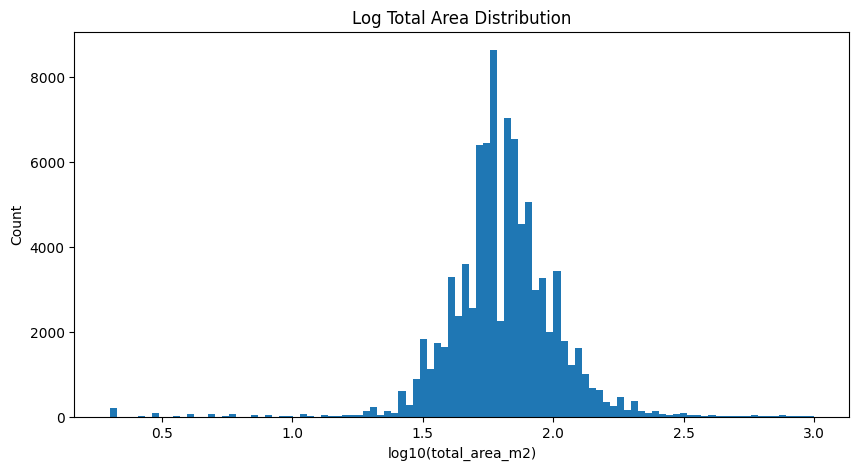

In [46]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['total_area_m2']+1), bins=100)
plt.xlabel("log10(total_area_m2)")
plt.ylabel("Count")
plt.title("Log Total Area Distribution")
plt.show()


In [47]:
lower = max(lower, 10)
upper = 400

df_cleaned_1 = df_cleaned_1[
    df_cleaned_1['total_area_m2'].between(lower, upper)
]

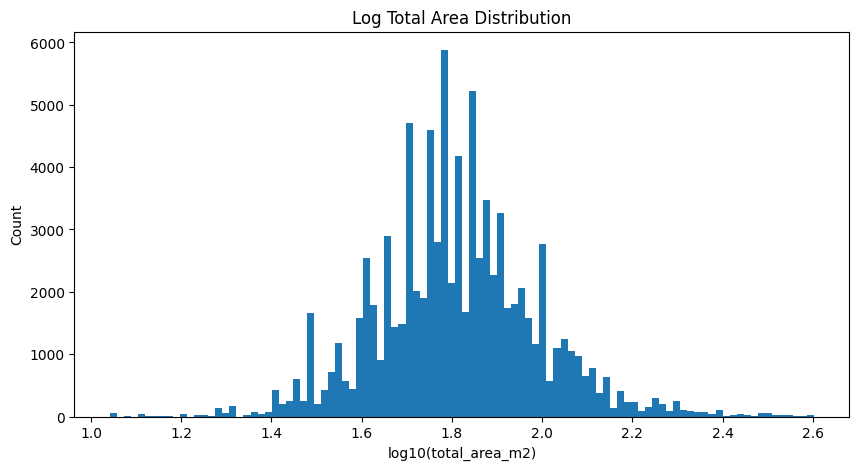

In [48]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['total_area_m2']+1), bins=100)
plt.xlabel("log10(total_area_m2)")
plt.ylabel("Count")
plt.title("Log Total Area Distribution")
plt.show()

In [49]:
print(len(df_cleaned_1))

88438


## `floor` & `total_floors` Tozalash jarayoni

In [50]:
df_cleaned_1['floor'].describe()

count    88436.000000
mean         4.859265
std          4.986339
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max        904.000000
Name: floor, dtype: float64

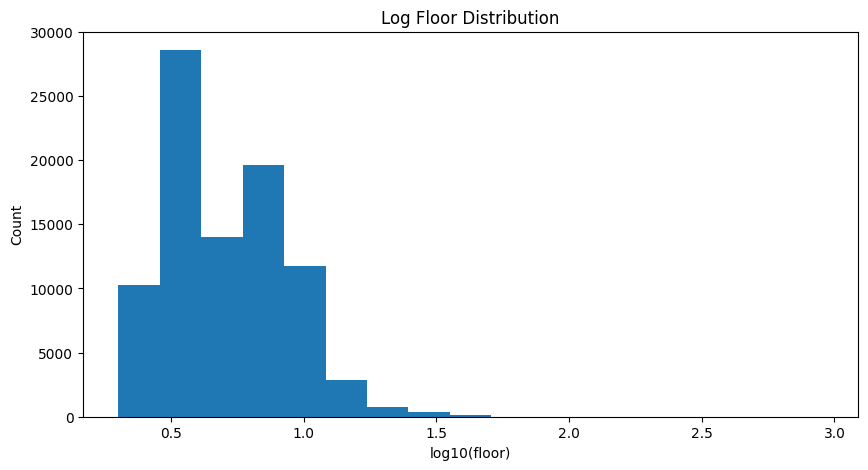

In [51]:
plt.figure(figsize=(10,5))
plt.hist(np.log10(df_cleaned_1['floor']+1),bins=17)
plt.xlabel("log10(floor)")
plt.ylabel("Count")
plt.title("Log Floor Distribution")
plt.show()

In [52]:
df_cleaned_1['floor'].value_counts()


floor
3.0      14592
4.0      14004
2.0      13990
1.0      10254
5.0       8850
6.0       5399
7.0       5350
8.0       4885
9.0       3880
10.0      2030
12.0      1025
11.0       982
13.0       549
14.0       532
15.0       480
16.0       311
18.0       174
17.0       169
20.0       103
22.0        99
23.0        99
24.0        82
19.0        69
21.0        69
25.0        53
27.0        44
34.0        42
31.0        39
32.0        35
26.0        31
40.0        30
35.0        27
30.0        25
39.0        16
44.0        14
37.0        14
33.0        13
42.0        12
29.0        11
36.0        10
43.0         9
45.0         8
38.0         7
28.0         4
47.0         3
63.0         2
60.0         2
54.0         1
67.0         1
55.0         1
48.0         1
61.0         1
120.0        1
41.0         1
904.0        1
Name: count, dtype: int64

In [53]:
df_cleaned_1.loc[df_cleaned_1['floor'] > 30, ["price_usd","total_area_m2", "rooms", "floor", "total_floors","url"]]

,price_usd,total_area_m2,rooms,floor,total_floors,url
634,2200.0,120.0,3.0,34.0,51.0,https://www.olx.uz/d/obyavlenie/zhk-nest-one-s...
786,165000.0,65.0,2.0,31.0,48.0,https://www.olx.uz/d/obyavlenie/uspey-kupit-2-...
951,155000.0,59.0,2.0,37.0,48.0,https://www.olx.uz/d/obyavlenie/srochno-nedoro...
1433,280000.0,64.0,2.0,35.0,48.0,https://www.olx.uz/d/obyavlenie/prodaetsya-shi...
1510,3490.0,80.0,3.0,40.0,51.0,https://www.olx.uz/d/obyavlenie/nestone-a-blok...
...,...,...,...,...,...,...
92188,238000.0,100.0,3.0,32.0,49.0,https://www.olx.uz/d/obyavlenie/piramit-tover-...
92190,249000.0,97.0,3.0,34.0,45.0,https://www.olx.uz/d/obyavlenie/novostroyka-pi...
92579,2300.0,80.0,3.0,40.0,51.0,https://www.olx.uz/d/obyavlenie/nest-one-arend...
92911,160000.0,66.0,2.0,37.0,48.0,https://www.olx.uz/d/obyavlenie/piramit-tower-...


In [54]:
df_cleaned_1 = df_cleaned_1[df_cleaned_1['floor'] < 100]

In [55]:
df_cleaned_1["total_floors"].value_counts()

total_floors
4.0      20468
9.0      16812
5.0      12398
10.0      5765
7.0       4951
         ...  
74.0         1
54.0         1
650.0        1
60.0         1
500.0        1
Name: count, Length: 66, dtype: int64

In [56]:
df_cleaned_1 = df_cleaned_1[df_cleaned_1['total_floors'] < 100]

## `building_type` tozalash jarayoni 

In [57]:
df_cleaned_1["building_type"].value_counts()

building_type
brick                                                         40006
panel                                                         16015
monolith                                                       8773
block                                                          1538
Деревянный                                                      170
Панель                                                           32
панель-середина                                                  12
кирпич                                                            6
.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}        6
Панельный Планировка: Раздельный                                  5
Монолит                                                           4
монолит                                                           2
Кирпич                                                            2
монолитная                                                        1
77-серия, имеется 6м балкон       

In [58]:
df_cleaned_1.isna().sum()

listing_id            0
source                0
seller_type           0
housing_type      30666
region                0
district              0
rooms                 0
total_area_m2         0
floor                 0
total_floors          0
building_type     21850
layout            31665
build_year        61780
ceiling_height    56290
bathroom          24730
furnished             1
renovation        16539
commission            0
amenities         32269
nearby            28663
negotiable            0
price                 0
currency              0
published_date        0
description           0
date_scraped          0
url                   0
price_usd             0
listing_type          0
price_per_sqr     31125
dtype: int64

In [59]:
def clean_building_type(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if "css" in value:
        return np.nan

    if "кирп" in value or "brick" in value:
        return "brick"

    if "панел" in value or "panel" in value:
        return "panel"

    if "монолит" in value or "monolith" in value:
        return "monolith"

    if "блок" in value or "block" in value or "газоблок" in value:
        return "block"

    if "дерев" in value:
        return "wood"

    return np.nan

In [60]:
df_cleaned_1["building_type"] = df_cleaned_1["building_type"].apply(clean_building_type)

df_cleaned_1["building_type"].value_counts(dropna=False)

building_type
brick       40017
NaN         21857
panel       16065
monolith     8780
block        1539
wood          170
Name: count, dtype: int64

## `layout` tozalash jarayoni

In [61]:
df_cleaned_1['layout'].value_counts()

layout
separate                                                                         43512
Смежно-раздельная                                                                 4425
adjacent                                                                          4179
studio                                                                            2866
Многоуровневая                                                                     619
                                                                                 ...  
Алоҳида (раздельная)                                                                 1
двусторонняя, 2 санузла, открытый балкон, гардеробная.                               1
Захватывающий вид на площадь, торговый центр и протекающую рядом реку Бурджар        1
спец-план, панел                                                                     1
Сквозная и двухсторонняя                                                             1
Name: count, Length: 101, dtype: int

In [62]:
def clean_layout(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["-", ""]:
        return np.nan

    if "css" in value:
        return np.nan

    if "studio" in value or "студ" in value:
        return "studio"

    if "free layout" in value or "свобод" in value:
        return "free_layout"

    if "пентхаус" in value or "penthouse" in value:
        return "penthouse"

    if "многоуров" in value:
        return "multi_level"

    if "малосем" in value:
        return "small_family"

    if (
        "смежно" in value
        or "см-раз" in value
        or "см раз" in value
        or "сможно" in value
    ):
        return "adjacent_separate"

    if "смеж" in value:
        return "adjacent"

    if (
        "раздел" in value
        or "раздель" in value
        or "алоҳида" in value
        or "alohida" in value
        or value == "separate"
    ):
        return "separate"

    if "adjacent" in value:
        return "adjacent"

    return np.nan

df_cleaned_1["layout"] = df_cleaned_1["layout"].apply(clean_layout)

df_cleaned_1["layout"].value_counts(dropna=False)

layout
separate             43630
NaN                  31834
adjacent_separate     4439
adjacent              4272
studio                2872
multi_level            619
small_family           589
penthouse              171
free_layout              2
Name: count, dtype: int64

## `build_year` tozalash jarayoni

In [63]:
df_cleaned_1["build_year"].describe()

count    26648.000000
mean      2006.517712
std         15.954496
min       1960.000000
25%       1989.000000
50%       2015.000000
75%       2019.000000
max       2025.000000
Name: build_year, dtype: float64

In [64]:
df_cleaned_1[df_cleaned_1["build_year"].isna()]

,listing_id,source,seller_type,housing_type,region,district,rooms,total_area_m2,floor,total_floors,...,negotiable,price,currency,published_date,description,date_scraped,url,price_usd,listing_type,price_per_sqr
3,4aiOy,olx,private,NaN,Tashkent Region,Shaykhantakhur,3.0,67.5,5.0,6.0,...,0,1400.0,USD,02/05/2026,"Описание Квартира в новостройке Tashkent City,...",2026-05-02,https://www.olx.uz/d/obyavlenie/sdaetsya-v-are...,1400.0,Rent,NaN
4,4mAGS,olx,business,resale,Tashkent Region,Yashnabad,3.0,78.0,1.0,4.0,...,0,120000.0,USD,02/05/2026,Описание Продается своя квартира 3/1/4 Кирпичн...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-3-1-4...,120000.0,Sale,1538.46
8,4cXVi,olx,business,resale,Tashkent Region,Mirzo Ulugbek,1.0,28.0,4.0,5.0,...,0,65000.0,USD,02/05/2026,Описание Новомосковская 1комнатная кирпич Мирз...,2026-05-02,https://www.olx.uz/d/obyavlenie/kvartira-1-kom...,65000.0,Sale,2321.43
9,4mfGl,olx,business,new building,Tashkent Region,Yakkasaray,4.0,122.0,2.0,8.0,...,1,310000.0,USD,02/05/2026,Описание ПРОДАЕТСЯ 4/2/8 НОВОСТРОЙКА ЖК Dream ...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochno-novost...,310000.0,Sale,2540.98
10,4lw2N,olx,business,new building,Tashkent Region,Yakkasaray,4.0,108.0,4.0,8.0,...,1,240000.0,USD,02/05/2026,Описание Продаётся квартира ЖК Dream House #Як...,2026-05-02,https://www.olx.uz/d/obyavlenie/srochnaya-prod...,240000.0,Sale,2222.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93465,4poOS,olx,private,NaN,Tashkent Region,Almazar,2.0,60.0,3.0,9.0,...,1,600.0,USD,28/06/2026,Описание Golden House Sagbon узок муддатга аре...,2026-06-28,https://www.olx.uz/d/obyavlenie/uzoq-muddatga-...,600.0,Rent,NaN
93467,4b9XR,olx,private,new building,Tashkent Region,Chilanzar,4.0,128.5,1.0,6.0,...,0,1300.0,USD,27/06/2026,Описание Продаётся 4/1/6 с подвалом на Чиланз...,2026-06-28,https://www.olx.uz/d/obyavlenie/prodaetsya-4-1...,1300.0,Rent,NaN
93472,45rWz,olx,private,NaN,Tashkent Region,Almazar,2.0,30.0,3.0,4.0,...,0,800000.0,UZS,09/06/2026,Описание assalomu aleykum ijaraga uy bor qizla...,2026-06-28,https://www.olx.uz/d/obyavlenie/ijaraga-uy-ber...,63.0,Rent,NaN
93473,4oaci,olx,business,resale,Tashkent Region,Mirabad,3.0,80.0,2.0,4.0,...,1,135000.0,USD,27/06/2026,Описание ВТОРИЧКА! 3/2/5 Ул. Фаргона Йули Ор-р...,2026-06-28,https://www.olx.uz/d/obyavlenie/vtorichka-3-2-...,135000.0,Sale,1687.50


In [65]:
from datetime import datetime

current_year = datetime.now().year

df_cleaned_1["build_year"] = pd.to_numeric(df_cleaned_1["build_year"], errors="coerce")

df_cleaned_1["age"] = current_year - df_cleaned_1['build_year']

df_cleaned_1.loc[
    (df_cleaned_1["build_year"] < 1900) |
    (df_cleaned_1["build_year"] > current_year),
    "age"
] = np.nan


df_cleaned_1["age"].describe()

count    26648.000000
mean        19.482288
std         15.954496
min          1.000000
25%          7.000000
50%         11.000000
75%         37.000000
max         66.000000
Name: age, dtype: float64

In [66]:
df_cleaned_1.sample(5)

,listing_id,source,seller_type,housing_type,region,district,rooms,total_area_m2,floor,total_floors,...,price,currency,published_date,description,date_scraped,url,price_usd,listing_type,price_per_sqr,age
72641,4nAut,olx,business,new building,Tashkent Region,Mirzo Ulugbek,2.0,70.0,4.0,6.0,...,125000.0,USD,21/05/2026,Описание Мирзо Улугбекский район . м-Ялангач ...,2026-05-21,https://www.olx.uz/d/obyavlenie/2-4-6-70m2-m-y...,125000.0,Sale,1785.71,NaN
9725,4lWL1,olx,business,NaN,Samarkand Region,Samarkand,3.0,78.0,3.0,5.0,...,2500000.0,UZS,03/05/2026,Описание Diqqat oilaga yoki studentlarga Uy Ma...,2026-05-03,https://www.olx.uz/d/obyavlenie/samarqand-ijar...,196.9,Rent,NaN,26.0
52775,4nbgP,olx,business,resale,Tashkent Region,Yakkasaray,3.0,70.0,4.0,9.0,...,105000.0,USD,13/05/2026,Описание Kvartira Yakkasaroy tumani Bobur 69/...,2026-05-13,https://www.olx.uz/d/obyavlenie/toshkent-yakka...,105000.0,Sale,1500.00,NaN
33974,4mUvQ,olx,business,resale,Tashkent Region,Chilanzar,2.0,52.0,1.0,4.0,...,76000.0,USD,07/05/2026,Описание #Чиланзар9квартал #Чиланзар2комнатная...,2026-05-07,https://www.olx.uz/d/obyavlenie/chul-9-panel-2...,76000.0,Sale,1461.54,NaN
100,4lS9f,olx,business,resale,Tashkent Region,Yunusabad,2.0,50.0,3.0,4.0,...,68000.0,USD,01/05/2026,Описание #2комнатная Юнусабад 4квартал 2в3/3/4...,2026-05-02,https://www.olx.uz/d/obyavlenie/yunusabad-4-kv...,68000.0,Sale,1360.00,NaN


## `ceiling_height` tozalash jarayoni

In [67]:
print(f"Missing values: {df_cleaned_1["ceiling_height"].isna().sum()}")

Missing values: 56290


In [68]:
print(df_cleaned_1["ceiling_height"].describe())

count    32138.000000
mean         3.013926
std          0.303235
min          2.000000
25%          3.000000
50%          3.000000
75%          3.000000
max          6.000000
Name: ceiling_height, dtype: float64


## `bathroom` tozalash jarayoni

In [69]:
print(df_cleaned_1['bathroom'].value_counts())

bathroom
separate                                                      32337
combined                                                      24288
2+ bathrooms                                                   6982
2                                                                32
3                                                                14
1                                                                 9
.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}        8
алоҳида                                                           3
4                                                                 3
совмещеный                                                        2
Совмешенный                                                       2
Разделный                                                         2
Совмещённый.                                                      2
совмещение                                                        2
2 санузла                              

In [70]:
def clean_bathroom(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip().replace(".", "")

    if value in ["", "-", "css"]:
        return np.nan

    if "css" in value:
        return np.nan

    if (
        value in ["2", "3", "4", "2 та"]
        or "2+" in value
        or "2 сан" in value
        or "2 та" in value
        or "3 сан" in value
        or "4 сан" in value
    ):
        return "2+ bathrooms"

    if (
        "separate" in value
        or "раздель" in value
        or "раздел" in value
        or "алоҳида" in value
        or "alohida" in value
    ):
        return "separate"

    if (
        "combined" in value
        or "совмещ" in value
        or "совмеш" in value
        or "совмещение" in value
    ):
        return "combined"

    return np.nan


df_cleaned_1["bathroom"] = df_cleaned_1["bathroom"].apply(clean_bathroom)

print(df_cleaned_1["bathroom"].value_counts(dropna=False))

bathroom
separate        32347
NaN             24749
combined        24297
2+ bathrooms     7035
Name: count, dtype: int64


## `furnished` tozalash jarayoni

In [71]:
df_cleaned_1["furnished"].value_counts()

furnished
1.0    66927
0.0    21500
Name: count, dtype: int64

## `renovation` tozalash jarayoni

In [72]:
df_cleaned_1["renovation"].value_counts()

renovation
euro renovation                    35402
average condition                  15064
designer renovation                13665
shell and core                      3128
needs renovation                    2716
                                   ...  
средний ремонт                         1
комфорт                                1
яхши, ўртача ҳолатда                   1
комфорт, ҳали яшалмаган                1
Без ремонта банк вариянтиям бор        1
Name: count, Length: 64, dtype: int64

In [73]:
categories_list = df_cleaned_1["renovation"].value_counts().index.to_list()

In [74]:
print(categories_list)

['euro renovation', 'average condition', 'designer renovation', 'shell and core', 'needs renovation', 'pre-finished', 'С ремонтом', 'Евро', 'Без ремонта', '.css-cgp8kk{border-top:1px solid #7F9799;margin-top:24px;}', 'евро', 'Хороший', 'Среднее состояние', 'Евро | с мебелью и техникой', 'хороший', 'евро люкс', 'коробка', 'Коробка', 'Авторский/Дизайнерский', 'комфорт, люкс', 'современный евро', 'Авторский ремонт', 'косметический', 'чистый ремонт', 'Новая никто не жил', 'Дизайнерский', 'как на фото', 'ўртача, тоза', 'Хорошиий', 'премиального класса, выполнен из качественных материалов', 'Под Евро', 'Черновая улучшенная', 'Чистый ремонт', 'евро ремонт', 'White Box', 'хороший ремонт', 'Средний Ремонт', 'Евро ремонт', 'новый ремонт', 'Авторский евроремонт в современном стиле. Использовались только качественные отделочные материалы.', 'без ремонта', 'ўртача', 'Требуется', 'яхши ҳолатда', 'современный, выполнен в светлых тонах', 'Евро-Люкс', 'новый, качественный', 'есть', 'Требуется ремонт', 

In [75]:
def clean_renovation(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    if value in ["", "-"]:
        return np.nan

    if "css" in value:
        return np.nan
    
    if value in ["йок", "йўқ", "yo'q", "yoq", "yuq", "yo‘q", "нет", "none", "no"]:
        return "needs_renovation"

    # No / needs renovation
    if (
        "без ремонта" in value
        or "требуется ремонт" in value
        or "needs renovation" in value
        or "ремонт керак" in value
    ):
        return "needs_renovation"

    # Shell/core / unfinished
    if (
        "shell" in value
        or "core" in value
        or "коробка" in value
        or "чернов" in value
    ):
        return "shell_and_core"

    # Pre-finished / white box
    if (
        "pre-finished" in value
        or "white box" in value
        or "предчист" in value
    ):
        return "pre_finished"

    # Designer / author renovation
    if (
        "designer" in value
        or "дизайнер" in value
        or "авторск" in value
        or "haytec" in value
    ):
        return "designer_renovation"

    # Euro / luxury / modern renovation
    if (
        "euro" in value
        or "евро" in value
        or "люкс" in value
        or "lux" in value
        or "современ" in value
        or "комфорт" in value
    ):
        return "euro_renovation"

    # Average / good condition
    if (
        "average" in value
        or "сред" in value
        or "хорош" in value
        or "яхши" in value
        or "чистый" in value
        or "космет" in value
        or "как на фото" in value
        or "с ремонтом" in value
        or value == "есть"
    ):
        return "average_condition"

    return np.nan

In [76]:
df_cleaned_1["renovation"] = df_cleaned_1["renovation"].apply(clean_renovation)

df_cleaned_1["renovation"].value_counts(dropna=False)

renovation
euro_renovation        35569
NaN                    16562
average_condition      15363
designer_renovation    13678
shell_and_core          3137
needs_renovation        2788
pre_finished            1331
Name: count, dtype: int64

## `commission` tozalash jarayoni

In [77]:
df_cleaned_1['commission'].value_counts()

commission
0.0    61237
1.0    27191
Name: count, dtype: int64

## `amenities` tozalash jarayoni

In [78]:
df_cleaned_1['amenities'].value_counts()

amenities
Internet, Telephone, Refrigerator, TV, Air Conditioning, Cable TV, Washing Machine, Kitchen, Balcony    17840
Kitchen, TV, Balcony, Air Conditioning, Internet, Cable TV, Telephone, Washing Machine, Refrigerator     2181
Cable TV, TV, Telephone, Balcony, Washing Machine, Air Conditioning, Refrigerator, Internet, Kitchen     2131
Kitchen, Balcony                                                                                         2119
Internet, Refrigerator, TV, Air Conditioning, Cable TV, Washing Machine, Kitchen, Balcony                1940
                                                                                                        ...  
Air Conditioning, Cable TV, Washing Machine, Kitchen                                                        1
Refrigerator, Cable TV, Washing Machine                                                                     1
Kitchen, Cable TV, Balcony, Washing Machine, TV                                                             1


## `nearby` tozalash jarayoni

In [79]:
df_cleaned_1['nearby'].value_counts()

nearby
Hospital, Clinic, Playground, Kindergarten, Bus Stop, Park, Green Area, Entertainment, Restaurant, Cafe, Parking, Supermarket, Shops, School    20767
Hospital, Clinic, School, Playground, Kindergarten, Bus Stop, Park, Green Area, Entertainment, Restaurant, Cafe, Parking, Supermarket, Shops    12858
Entertainment, Bus Stop, School, Supermarket, Shops, Restaurant, Cafe, Playground, Park, Green Area, Kindergarten, Hospital, Clinic, Parking     4182
Restaurant, Cafe, Kindergarten, Parking, Bus Stop, Hospital, Clinic, Supermarket, Shops, Park, Green Area, School, Entertainment, Playground     3914
Hospital, Clinic, Playground, Kindergarten, Bus Stop, Park, Green Area, Entertainment, Restaurant, Cafe, Parking, Supermarket, Shops             1370
                                                                                                                                                ...  
Kindergarten, Park, Green Area, Entertainment, Restaurant, Cafe, Supermarket, Shops, School  

In [80]:
metro_pattern = r"metro|метро"

df_cleaned_1["near_metro_mentioned"] = (
    df_cleaned_1["description"].fillna("").str.contains(metro_pattern, case = False, regex = True) 
    |
    df_cleaned_1["url"].fillna("").str.contains(metro_pattern, case = False, regex = True)
).astype(int)

df_cleaned_1["near_metro_mentioned"].value_counts()


near_metro_mentioned
0    73573
1    14855
Name: count, dtype: int64

In [81]:
VALID_NEARBY = {
    "Hospital", "Clinic", "Playground", "Kindergarten", "Bus Stop",
    "Park", "Green Area", "Entertainment", "Restaurant", "Cafe",
    "Parking", "Supermarket", "Shops", "School", "Metro",
}

NEARBY_ALIASES = {
    "метро": "Metro",
    "metro": "Metro",
}

def clean_multi_value_items(value, valid_items=None):
    if pd.isna(value):
        return ""

    items = [item.strip() for item in str(value).split(",")]
    items = [NEARBY_ALIASES.get(item.lower(), item) for item in items]

    if valid_items is not None:
        items = [item for item in items if item in valid_items]

    return ", ".join(items)


def create_boolean_columns(df, column_name, prefix, valid_items=None):
    old_dummy_cols = [col for col in df.columns if col.startswith(f"{prefix}_")]
    df = df.drop(columns=old_dummy_cols, errors="ignore")

    cleaned_values = df[column_name].apply(
        lambda value: clean_multi_value_items(value, valid_items)
    )

    dummies = cleaned_values.str.get_dummies(sep=", ")

    dummies.columns = [
        f"{prefix}_{col.lower().strip().replace(' ', '_')}"
        for col in dummies.columns
    ]

    return pd.concat([df, dummies], axis=1)

In [82]:
df_cleaned_1 = create_boolean_columns(df_cleaned_1, "amenities", "amenity")
df_cleaned_1 = create_boolean_columns(df_cleaned_1, "nearby", "nearby", VALID_NEARBY)

In [83]:
df_cleaned_1.filter(like="amenity_").head()
df_cleaned_1.filter(like="nearby_").head()

,nearby_bus_stop,nearby_cafe,nearby_clinic,nearby_entertainment,nearby_green_area,nearby_hospital,nearby_kindergarten,nearby_metro,nearby_park,nearby_parking,nearby_playground,nearby_restaurant,nearby_school,nearby_shops,nearby_supermarket
0,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1
1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1


In [84]:
excel_apartment_cleaned = df_cleaned_1[[
    'listing_id',
    'url',

    'listing_type',
    'seller_type',
    'housing_type',

    'region',
    'district',

    'rooms',
    'total_area_m2',
    'price',
    'currency',
    'price_usd',
    'price_per_sqr',

    'floor',
    'total_floors',
    'building_type',
    'layout',
    'build_year',
    'age',
    'ceiling_height',

    'bathroom',
    'furnished',
    'renovation',
    'amenity_air_conditioning',
    'amenity_balcony',
    'amenity_cable_tv', 
    'amenity_internet', 
    'amenity_kitchen',
    'amenity_refrigerator', 
    'amenity_tv', 
    'amenity_telephone',
    'amenity_washing_machine', 
    'nearby_bus_stop', 
    'nearby_cafe',
    'nearby_clinic', 
    'nearby_entertainment', 
    'nearby_green_area',
    'nearby_hospital', 
    'nearby_kindergarten', 
    'nearby_park',
    'nearby_parking', 
    'nearby_playground', 
    'nearby_restaurant',
    'nearby_school', 
    'nearby_shops', 
    'nearby_supermarket', 
    "near_metro_mentioned",

    'commission',
    'negotiable',

    'published_date',
    'date_scraped',
]].copy()

In [85]:
df_cleaned_1.columns

Index(['listing_id', 'source', 'seller_type', 'housing_type', 'region',
       'district', 'rooms', 'total_area_m2', 'floor', 'total_floors',
       'building_type', 'layout', 'build_year', 'ceiling_height', 'bathroom',
       'furnished', 'renovation', 'commission', 'amenities', 'nearby',
       'negotiable', 'price', 'currency', 'published_date', 'description',
       'date_scraped', 'url', 'price_usd', 'listing_type', 'price_per_sqr',
       'age', 'near_metro_mentioned', 'amenity_air_conditioning',
       'amenity_balcony', 'amenity_cable_tv', 'amenity_internet',
       'amenity_kitchen', 'amenity_refrigerator', 'amenity_tv',
       'amenity_telephone', 'amenity_washing_machine',
       'amenity_детская_площадка', 'amenity_детский_сад', 'amenity_остановки',
       'amenity_парк', 'amenity_развлекательные_заведения',
       'amenity_рестораны', 'amenity_стоянка', 'amenity_супермаркет',
       'amenity_школа', 'amenity_школаремонт:_евроремонт',
       'amenity_зелёная_зона', 'amenity

In [86]:
database = df_cleaned_1[[
    ## LISTING_FACT
    'listing_id',
    'price_usd',
    'price_per_sqr',
    'listing_type',
    'commission',
    'negotiable',
    'published_date',
    'date_scraped',
    'url',
    'description',

    ## Property_dim
    'housing_type',
    'rooms',
    'total_area_m2',
    'floor',
    'total_floors',
    'building_type',
    'layout',
    'build_year',
    'age',
    'ceiling_height',
    'bathroom',
    'furnished',
    'renovation',

    ## SELLER_DIM
    'seller_type',

    ## LOCATION_DIM
    'region',
    'district',

    ## anenities
    'amenity_air_conditioning',
    'amenity_balcony',
    'amenity_cable_tv', 
    'amenity_internet', 
    'amenity_kitchen',
    'amenity_refrigerator', 
    'amenity_tv', 
    'amenity_telephone',
    'amenity_washing_machine', 
    ## nearby
    'nearby_bus_stop', 
    'nearby_cafe',
    'nearby_clinic', 
    'nearby_entertainment', 
    'nearby_green_area',
    'nearby_hospital', 
    'nearby_kindergarten', 
    'nearby_park',
    'nearby_parking', 
    'nearby_playground', 
    'nearby_restaurant',
    'nearby_school', 
    'nearby_shops', 
    'nearby_supermarket', 
    "near_metro_mentioned"
]].copy()

In [87]:
database.columns

Index(['listing_id', 'price_usd', 'price_per_sqr', 'listing_type',
       'commission', 'negotiable', 'published_date', 'date_scraped', 'url',
       'description', 'housing_type', 'rooms', 'total_area_m2', 'floor',
       'total_floors', 'building_type', 'layout', 'build_year', 'age',
       'ceiling_height', 'bathroom', 'furnished', 'renovation', 'seller_type',
       'region', 'district', 'amenity_air_conditioning', 'amenity_balcony',
       'amenity_cable_tv', 'amenity_internet', 'amenity_kitchen',
       'amenity_refrigerator', 'amenity_tv', 'amenity_telephone',
       'amenity_washing_machine', 'nearby_bus_stop', 'nearby_cafe',
       'nearby_clinic', 'nearby_entertainment', 'nearby_green_area',
       'nearby_hospital', 'nearby_kindergarten', 'nearby_park',
       'nearby_parking', 'nearby_playground', 'nearby_restaurant',
       'nearby_school', 'nearby_shops', 'nearby_supermarket',
       'near_metro_mentioned'],
      dtype='object')

In [88]:
database.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88428 entries, 0 to 93474
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   listing_id                88428 non-null  object 
 1   price_usd                 88428 non-null  float64
 2   price_per_sqr             57303 non-null  float64
 3   listing_type              88428 non-null  object 
 4   commission                88428 non-null  float64
 5   negotiable                88428 non-null  int64  
 6   published_date            88428 non-null  object 
 7   date_scraped              88428 non-null  object 
 8   url                       88428 non-null  object 
 9   description               88428 non-null  object 
 10  housing_type              57762 non-null  object 
 11  rooms                     88428 non-null  float64
 12  total_area_m2             88428 non-null  float64
 13  floor                     88428 non-null  float64
 14  total_floor

In [89]:
df_cleaned_1.sample(7)

,listing_id,source,seller_type,housing_type,region,district,rooms,total_area_m2,floor,total_floors,...,nearby_hospital,nearby_kindergarten,nearby_metro,nearby_park,nearby_parking,nearby_playground,nearby_restaurant,nearby_school,nearby_shops,nearby_supermarket
6475,4lTRH,olx,business,new building,Tashkent Region,Yakkasaray,3.0,90.0,9.0,10.0,...,1,1,0,1,1,1,1,1,1,1
1623,4lGcq,olx,business,NaN,Tashkent Region,Yakkasaray,4.0,200.0,5.0,10.0,...,1,1,0,1,1,1,1,1,1,1
93163,4olOz,olx,business,resale,Tashkent Region,Mirzo Ulugbek,2.0,64.0,5.0,5.0,...,1,1,0,1,1,1,1,1,1,1
73769,4fcpW,olx,business,resale,Tashkent Region,Sergeli,4.0,106.0,7.0,9.0,...,0,0,0,0,1,0,0,1,1,1
48106,4jVIr,olx,private,NaN,Surxondaryo Region,Termez,3.0,69.7,5.0,9.0,...,1,1,0,1,1,1,1,1,1,1
1477,41CrE,olx,business,NaN,Tashkent Region,Mirzo Ulugbek,2.0,47.0,3.0,9.0,...,1,1,0,1,1,1,1,1,0,0
36768,4mztT,olx,business,resale,Samarkand Region,Samarkand,1.0,35.0,2.0,4.0,...,1,1,0,1,1,1,1,1,1,1


In [90]:
database.to_csv("../data/Praperad/database.csv", index=False)

In [91]:
excel_apartment_cleaned.to_csv("../data/Praperad/excel_apartment_cleaned.csv", index=False)